In [21]:
import os
import re

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.datasets import fetch_20newsgroups, load_files
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, log_loss, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'retina'

Stochastic gradient descent

In [22]:
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

In [23]:
PATH_TO_WRITE_DATA = "../../../data/tmp/"
data_demo = pd.read_csv(os.path.join(DATA_PATH, "weights_heights.csv"))

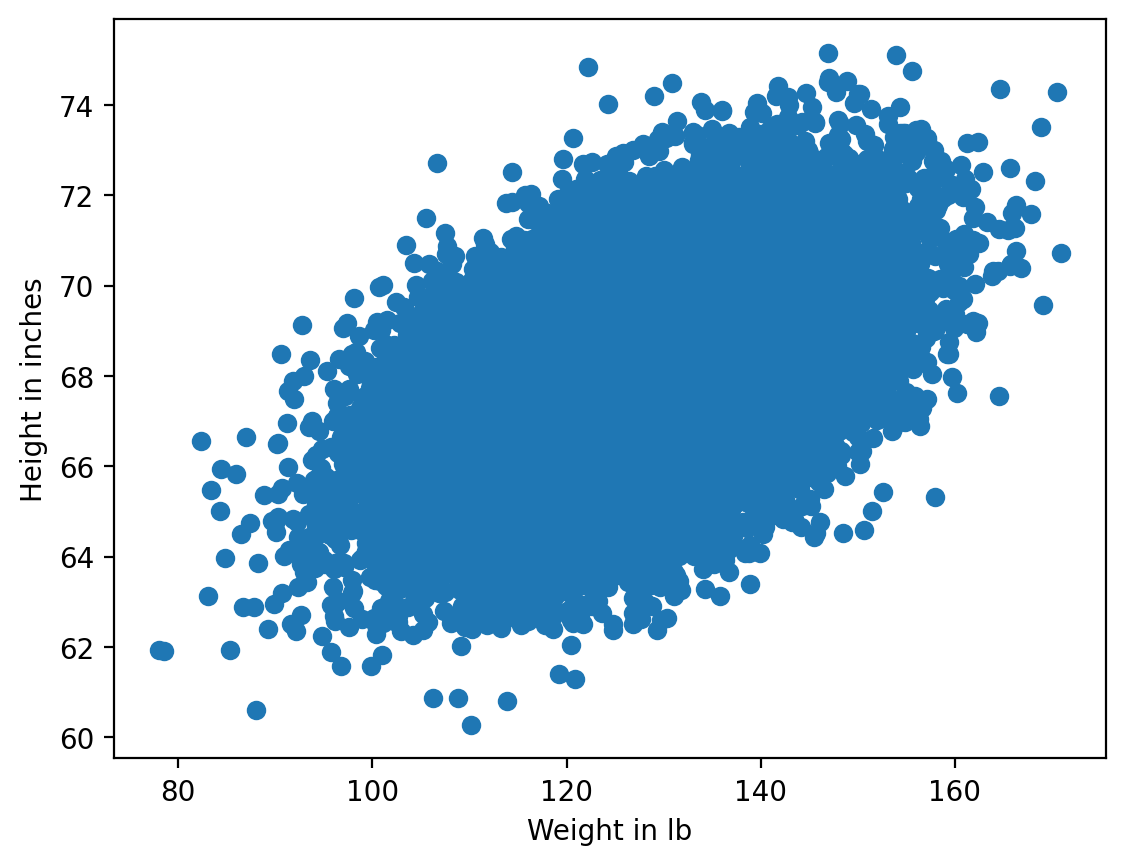

In [24]:
plt.scatter(data_demo["Weight"], data_demo["Height"])
plt.xlabel("Weight in lb")
plt.ylabel("Height in inches");

Categorical Feature Processing

Label Encoding

In [25]:
df = pd.read_csv(os.path.join(DATA_PATH, "bank_train.csv"))
labels = pd.read_csv(
    os.path.join(DATA_PATH, "bank_train_target.csv"), header=None
)

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,26,student,single,high.school,no,no,no,telephone,jun,mon,901,1,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1
1,46,admin.,married,university.degree,no,yes,no,cellular,aug,tue,208,2,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1
2,49,blue-collar,married,basic.4y,unknown,yes,yes,telephone,jun,tue,131,5,999,0,nonexistent,1.4,94.465,-41.8,4.864,5228.1
3,31,technician,married,university.degree,no,no,no,cellular,jul,tue,404,1,999,0,nonexistent,-2.9,92.469,-33.6,1.044,5076.2
4,42,housemaid,married,university.degree,no,yes,no,telephone,nov,mon,85,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8


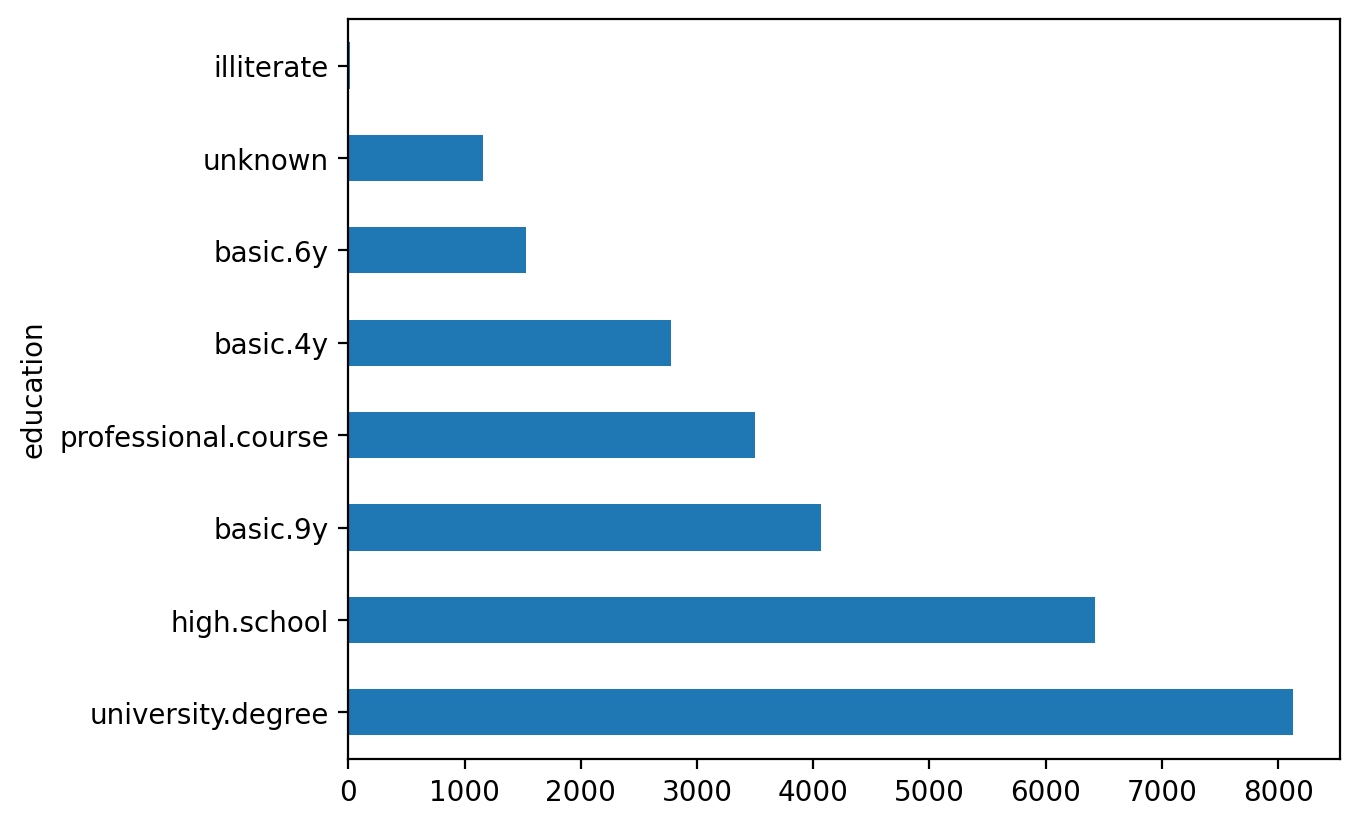

In [26]:
#most features not represented by numbers
#it's a problem because we cannot use most machine learning methods out of the box
#dive into education feature

df["education"].value_counts().plot.barh();


In [27]:
#straightforward solution is o map each value of this feature into a unique number

label_encoder = LabelEncoder()

{0: 'basic.4y', 1: 'basic.6y', 2: 'basic.9y', 3: 'high.school', 4: 'illiterate', 5: 'professional.course', 6: 'university.degree', 7: 'unknown'}


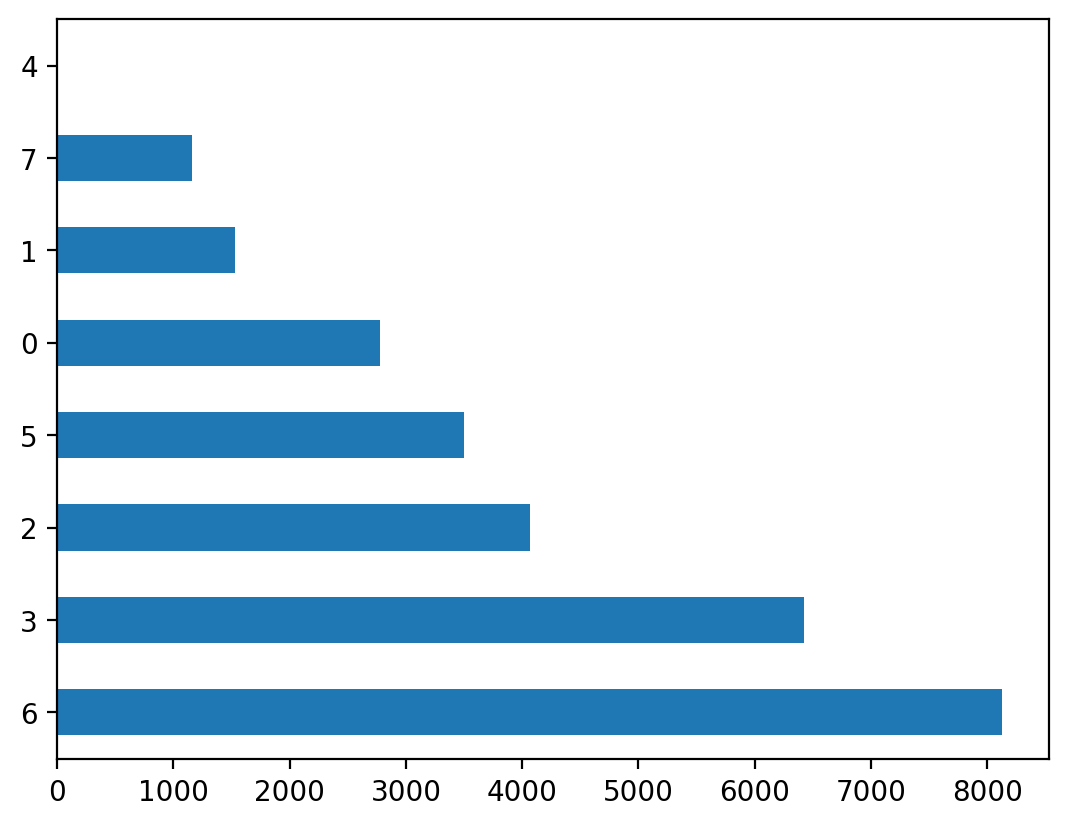

In [28]:
#the fit method o this class finds all unique values adn builds the ctual mapping betwee categories and numbers
#transform method converts the categories into numbers

mapped_education = pd.Series(label_encoder.fit_transform(df["education"]))
mapped_education.value_counts().plot.barh()
print(dict(enumerate(label_encoder.classes_)))

In [29]:
df["education"] = mapped_education
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,26,student,single,3,no,no,no,telephone,jun,mon,901,1,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1
1,46,admin.,married,6,no,yes,no,cellular,aug,tue,208,2,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1
2,49,blue-collar,married,0,unknown,yes,yes,telephone,jun,tue,131,5,999,0,nonexistent,1.4,94.465,-41.8,4.864,5228.1
3,31,technician,married,6,no,no,no,cellular,jul,tue,404,1,999,0,nonexistent,-2.9,92.469,-33.6,1.044,5076.2
4,42,housemaid,married,6,no,yes,no,telephone,nov,mon,85,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8


In [30]:
#transformation to the other columns of type object
categorical_columns = df.columns[df.dtypes == "object"].union(["education"])
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,26,student,single,3,no,no,no,telephone,jun,mon,901,1,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1
1,46,admin.,married,6,no,yes,no,cellular,aug,tue,208,2,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1
2,49,blue-collar,married,0,unknown,yes,yes,telephone,jun,tue,131,5,999,0,nonexistent,1.4,94.465,-41.8,4.864,5228.1
3,31,technician,married,6,no,no,no,cellular,jul,tue,404,1,999,0,nonexistent,-2.9,92.469,-33.6,1.044,5076.2
4,42,housemaid,married,6,no,yes,no,telephone,nov,mon,85,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8


In [31]:
#issue with this approach is that we have now introducedsome relative ordering here it might not exist
#we implicitly introduced algebra over the values of the job feature where we can substract the job of client#2 from the job of client#1
#this approach doesn't make sense, let's try to train logtictic regression with this feature transformation

def logistic_regression_accuracy_on(dataframe, labels):
    features = dataframe
    train_features, test_features, train_labels, test_labels = train_test_split(
        features, labels
    )

    logit = LogisticRegression()
    logit.fit(train_features, train_labels.values.ravel())
    return classification_report(test_labels, logit.predict(test_features))


print(logistic_regression_accuracy_on(df[categorical_columns], labels))


              precision    recall  f1-score   support

           0       0.88      1.00      0.94      6100
           1       0.00      0.00      0.00       799

    accuracy                           0.88      6899
   macro avg       0.44      0.50      0.47      6899
weighted avg       0.78      0.88      0.83      6899



/home/user/projects/ml-course/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/projects/ml-course/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/projects/ml-course/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [32]:
#logistic regression never predicts class 1. In order to use alinear models with categorial features, we use different approach

One-Hot Encoding

In [33]:
#suppose some feature can have10 unique values
#one hot encoding creates 10 new features corresponding to these unique values, all of the except one are zeros

one_hot_example = pd.DataFrame([{i: 0 for i in range(10)}])
one_hot_example.loc[0, 6] = 1
one_hot_example

,0,1,2,3,4,5,6,7,8,9
0,0,0,0,0,0,0,1,0,0,0


In [34]:
#by default onehotenconder transfors data into a sparse matrix to save memory space
#however, in this particular example such problem doesn't exist, so we use a dense matrix representation
onehot_encoder = OneHotEncoder(sparse_output=False)

In [35]:
encoded_categorical_columns = pd.DataFrame(
    onehot_encoder.fit_transform(df[categorical_columns])
)
encoded_categorical_columns.head()

,0,1,2,3,4,5,6,7
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [36]:
#we have 53 columns that correspond to the number of unique values 
#when transformae with one-hot encoding, this data can be used with linear models
print(logistic_regression_accuracy_on(encoded_categorical_columns, labels))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      6080
           1       0.00      0.00      0.00       819

    accuracy                           0.88      6899
   macro avg       0.44      0.50      0.47      6899
weighted avg       0.78      0.88      0.83      6899



/home/user/projects/ml-course/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/projects/ml-course/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/projects/ml-course/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

Hashing Trick

In [37]:
#since daa is volative, we cannot garatee that new values of categorial features will not occur
#hash functions ca help us ind unique codes for difrent feature values
for s in ("university.degree", "high.school", "illiterate"):
    print(s, "->", hash(s))

university.degree -> 6690246784773806100
high.school -> -6175926775265411489
illiterate -> -7203509011414059840


In [38]:
#we will not use negatvie values or values of high magnitude, so we restrict the range of values for the hash function
hash_space = 25
for s in ("university.degree", "high.school", "illiterate"):
    print(s, "->", hash(s) % hash_space)

university.degree -> 0
high.school -> 11
illiterate -> 10


In [39]:
hashing_example = pd.DataFrame([{i: 0.0 for i in range(hash_space)}])
for s in ("job=student", "marital=single", "day_of_week=mon"):
    print(s, "->", hash(s) % hash_space)
    hashing_example.loc[0, hash(s) % hash_space] = 1
hashing_example

job=student -> 19
marital=single -> 2
day_of_week=mon -> 24


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [40]:
#we hash not only feature values, but also pairs of feature name + feature value
assert hash("no") == hash("no")
assert hash("housing=no") != hash("loan=no")

Vowpal Wabbit

In [41]:
#VW is a good choice for working with text data
!vw --help | head

Num weight bits = 18
learning rate = 0.5
initial_t = 0
power_t = 0.5
using no cache
Reading datafile = 
num sources = 1

VW options:
  --ring_size arg                       size of example ring
  --onethread                           Disable parse thread

Update options:
  -l [ --learning_rate ] arg            Set learning rate
  --power_t arg                         t power value
  --decay_learning_rate arg             Set Decay factor for learning_rate 
                                        between passes


In [42]:
#Label is a number. In the case of classification, it is usually 1 and -1; for regression, it is a real float value
#Importance is a number. It denotes the sample weight during training. Setting this helps when working with imbalanced data.
#Tag is a string without spaces. It is the “name” of the sample that VW saves upon prediction. In order to separate Tag from Importance, it is better to start Tag with the ‘ character.
#Namespace is for creating different feature spaces.
#Features are object features inside a given Namespace. Features have weight 1.0 by default, but it can be changed, for example feature:0.1.

import vowpalwabbit as vw

model = vw.Workspace(quiet=True)

example = "1 1.0 |Subject WHAT car is this |Organization University of Maryland:0.5 College Park"
model.learn(example)

print(model.predict(example))

0.7942593097686768


In [43]:
! echo '1 1.0 |Subject WHAT car is this |Organization University of Maryland:0.5 College Park' | vw

Num weight bits = 18
learning rate = 0.5
initial_t = 0
power_t = 0.5
using no cache
Reading datafile = 
num sources = 1
average  since         example        example  current  current  current
loss     last          counter         weight    label  predict features
1.000000 1.000000            1            1.0   1.0000   0.0000       10

finished run
number of examples = 1
weighted example sum = 1.000000
weighted label sum = 1.000000
average loss = 1.000000
best constant = 1.000000
best constant's loss = 0.000000
total feature number = 10


3.1. News. Binary Classification

In [44]:
# load data with sklearn's function
from sklearn.datasets import fetch_20newsgroups
from pathlib import Path

PATH_TO_WRITE_DATA = Path("data")  # or: Path("/home/user/projects/ml-course/data")
PATH_TO_WRITE_DATA.mkdir(parents=True, exist_ok=True)

newsgroups = fetch_20newsgroups(data_home=PATH_TO_WRITE_DATA)

In [45]:
newsgroups["target_names"]

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [46]:
text = newsgroups["data"][0]
target = newsgroups["target_names"][newsgroups["target"][0]]

print("-----")
print(target)
print("-----")
print(text.strip())
print("----")

-----
rec.autos
-----
From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----
----


In [47]:
import re

In [48]:
#convert data into something vowpal wabbit can understand

def to_vw_format(document, label=None):
    return (
        str(label or "")
        + " |text "
        + " ".join(re.findall("\w{3,}", document.lower()))
        + "\n"
    )


to_vw_format(text, 1 if target == "rec.autos" else -1)

<>:7: SyntaxWarning: invalid escape sequence '\w'
<>:7: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_1076/28085895.py:7: SyntaxWarning: invalid escape sequence '\w'
  + " ".join(re.findall("\w{3,}", document.lower()))


'1 |text from lerxst wam umd edu where thing subject what car this nntp posting host rac3 wam umd edu organization university maryland college park lines was wondering anyone out there could enlighten this car saw the other day was door sports car looked from the late 60s early 70s was called bricklin the doors were really small addition the front bumper was separate from the rest the body this all know anyone can tellme model name engine specs years production where this car made history whatever info you have this funky looking car please mail thanks brought you your neighborhood lerxst\n'

In [49]:
all_documents = newsgroups["data"]
all_targets = [
    1 if newsgroups["target_names"][target] == "rec.autos" else -1
    for target in newsgroups["target"]
]

In [50]:
import os
from sklearn.model_selection import train_test_split

train_documents, test_documents, train_labels, test_labels = train_test_split(
    all_documents, all_targets, random_state=7
)

with open(os.path.join(PATH_TO_WRITE_DATA, "20news_train.vw"), "w") as vw_train_data:
    for text, target in zip(train_documents, train_labels):
        vw_train_data.write(to_vw_format(text, target))
with open(os.path.join(PATH_TO_WRITE_DATA, "20news_test.vw"), "w") as vw_test_data:
    for text in test_documents:
        vw_test_data.write(to_vw_format(text))

In [51]:
#create training file to vowpal wabbit

!vw -d $PATH_TO_WRITE_DATA/20news_train.vw --loss_function hinge -f $PATH_TO_WRITE_DATA/20news_model.vw

final_regressor = data/20news_model.vw
Num weight bits = 18
learning rate = 0.5
initial_t = 0
power_t = 0.5
using no cache
Reading datafile = data/20news_train.vw
num sources = 1
average  since         example        example  current  current  current
loss     last          counter         weight    label  predict features
1.000000 1.000000            1            1.0  -1.0000   0.0000      157
0.911276 0.822551            2            2.0  -1.0000  -0.1774      159
0.605793 0.300311            4            4.0  -1.0000  -0.3994       92
0.419594 0.233394            8            8.0  -1.0000  -0.8167      129
0.313998 0.208402           16           16.0  -1.0000  -0.6509      108
0.196014 0.078029           32           32.0  -1.0000  -1.0000      115
0.183158 0.170302           64           64.0  -1.0000  -0.7072      114
0.261046 0.338935          128          128.0   1.0000  -0.7900      110
0.262910 0.264774          256          256.0  -1.0000  -0.6425       44
0.216663 0.170415 

In [52]:
#apply trained model to the test set
!vw -i $PATH_TO_WRITE_DATA/20news_model.vw -t -d $PATH_TO_WRITE_DATA/20news_test.vw -p $PATH_TO_WRITE_DATA/20news_test_predictions.txt

only testing
predictions = data/20news_test_predictions.txt
Num weight bits = 18
learning rate = 0.5
initial_t = 0
power_t = 0.5
using no cache
Reading datafile = data/20news_test.vw
num sources = 1
average  since         example        example  current  current  current
loss     last          counter         weight    label  predict features
    n.a.     n.a.            1            1.0  unknown   1.0000      349
    n.a.     n.a.            2            2.0  unknown  -1.0000       50
    n.a.     n.a.            4            4.0  unknown  -1.0000      251
    n.a.     n.a.            8            8.0  unknown  -1.0000      237
    n.a.     n.a.           16           16.0  unknown  -0.8978      106
    n.a.     n.a.           32           32.0  unknown  -1.0000      964
    n.a.     n.a.           64           64.0  unknown  -1.0000      261
    n.a.     n.a.          128          128.0  unknown   0.4621       82
    n.a.     n.a.          256          256.0  unknown  -1.0000      18

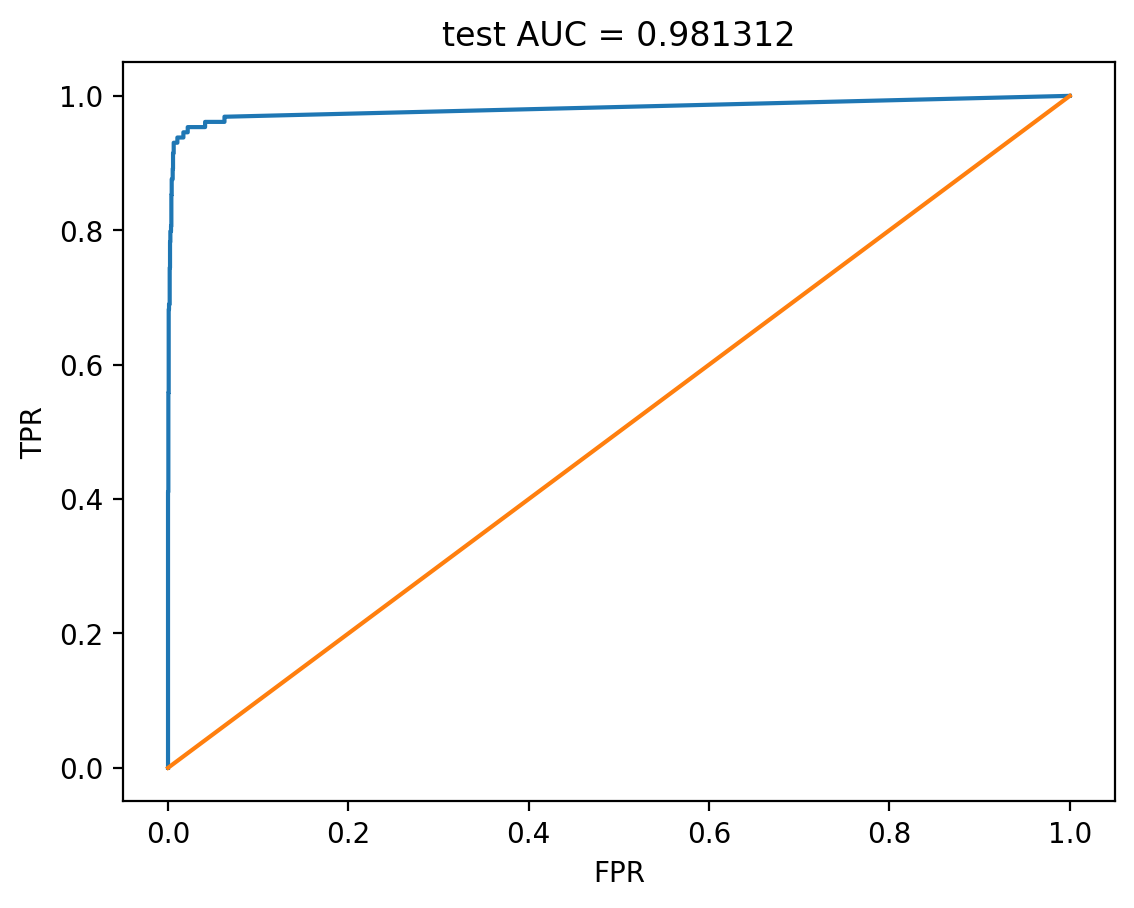

In [53]:
#load predictions, compute AUC and plot ROC curve
from sklearn.metrics import roc_auc_score, roc_curve

with open(os.path.join(PATH_TO_WRITE_DATA, "20news_test_predictions.txt")) as pred_file:
    test_prediction = [float(label) for label in pred_file.readlines()]

auc = roc_auc_score(test_labels, test_prediction)
roc_curve = roc_curve(test_labels, test_prediction)


plt.plot(roc_curve[0], roc_curve[1])
plt.plot([0, 1], [0, 1])
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("test AUC = %f" % (auc))
plt.axis([-0.05, 1.05, -0.05, 1.05]);

3.2. News. Multiclass classification

In [54]:
all_documents = newsgroups["data"]
topic_encoder = LabelEncoder()
all_targets_mult = topic_encoder.fit_transform(newsgroups["target"]) + 1

In [55]:
train_documents, test_documents, train_labels_mult, test_labels_mult = train_test_split(
    all_documents, all_targets_mult, random_state=7
)

with open(os.path.join(PATH_TO_WRITE_DATA, "20news_train_mult.vw"), "w") as vw_train_data:
    for text, target in zip(train_documents, train_labels_mult):
        vw_train_data.write(to_vw_format(text, target))
with open(os.path.join(PATH_TO_WRITE_DATA, "20news_test_mult.vw"), "w") as vw_test_data:
    for text in test_documents:
        vw_test_data.write(to_vw_format(text))

In [56]:
!vw --oaa 20 $PATH_TO_WRITE_DATA/20news_train_mult.vw -f $PATH_TO_WRITE_DATA/20news_model_mult.vw --loss_function=hinge

final_regressor = data/20news_model_mult.vw
Num weight bits = 18
learning rate = 0.5
initial_t = 0
power_t = 0.5
using no cache
Reading datafile = data/20news_train_mult.vw
num sources = 1
average  since         example        example  current  current  current
loss     last          counter         weight    label  predict features
1.000000 1.000000            1            1.0       15        1      157
1.000000 1.000000            2            2.0        2       15      159
1.000000 1.000000            4            4.0       15       10       92
1.000000 1.000000            8            8.0       16       15      129
1.000000 1.000000           16           16.0       13       12      108
0.937500 0.875000           32           32.0        2        9      115
0.906250 0.875000           64           64.0       16       16      114
0.867188 0.828125          128          128.0        8        4      110
0.816406 0.765625          256          256.0        7       15       44
0.646484

In [57]:
!vw -i $PATH_TO_WRITE_DATA/20news_model_mult.vw -t -d $PATH_TO_WRITE_DATA/20news_test_mult.vw -p $PATH_TO_WRITE_DATA/20news_test_predictions_mult.txt

only testing
predictions = data/20news_test_predictions_mult.txt
Num weight bits = 18
learning rate = 0.5
initial_t = 0
power_t = 0.5
using no cache
Reading datafile = data/20news_test_mult.vw
num sources = 1
average  since         example        example  current  current  current
loss     last          counter         weight    label  predict features
    n.a.     n.a.            1            1.0  unknown        8      349
    n.a.     n.a.            2            2.0  unknown        6       50
    n.a.     n.a.            4            4.0  unknown       18      251
    n.a.     n.a.            8            8.0  unknown       18      237
    n.a.     n.a.           16           16.0  unknown        4      106
    n.a.     n.a.           32           32.0  unknown       15      964
    n.a.     n.a.           64           64.0  unknown        4      261
    n.a.     n.a.          128          128.0  unknown        8       82
    n.a.     n.a.          256          256.0  unknown       

In [58]:
with open(
    os.path.join(PATH_TO_WRITE_DATA, "20news_test_predictions_mult.txt")
) as pred_file:
    test_prediction_mult = [float(label) for label in pred_file.readlines()]

In [59]:
accuracy_score(test_labels_mult, test_prediction_mult)

0.8734535171438671

In [60]:
M = confusion_matrix(test_labels_mult, test_prediction_mult)
for i in np.where(M[0, :] > 0)[0][1:]:
    print(newsgroups["target_names"][i], M[0, i])

rec.autos 1
rec.sport.baseball 1
sci.med 1
soc.religion.christian 3
talk.religion.misc 5


IMDB movie reviews

In [61]:
import tarfile
# Download the dataset if not already in place
from io import BytesIO

import requests

url = "http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"


def load_imdb_dataset(extract_path=PATH_TO_WRITE_DATA, overwrite=False):
    # check if existed already
    if (
        os.path.isfile(os.path.join(extract_path, "aclImdb", "README"))
        and not overwrite
    ):
        print("IMDB dataset is already in place.")
        return

    print("Downloading the dataset from:  ", url)
    response = requests.get(url)

    tar = tarfile.open(mode="r:gz", fileobj=BytesIO(response.content))

    data = tar.extractall(extract_path)


load_imdb_dataset()

/tmp/ipykernel_1076/700416260.py:24: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  data = tar.extractall(extract_path)


In [63]:
PATH_TO_IMDB = PATH_TO_WRITE_DATA / "aclImdb"

reviews_train = load_files(
    os.path.join(PATH_TO_IMDB, "train"), categories=["pos", "neg"]
)

text_train, y_train = reviews_train.data, reviews_train.target

In [64]:
print("Number of documents in training data: %d" % len(text_train))
print(np.bincount(y_train))

Number of documents in training data: 25000
[12500 12500]


In [65]:

reviews_test = load_files(os.path.join(PATH_TO_IMDB, "test"), categories=["pos", "neg"])
text_test, y_test = reviews_test.data, reviews_test.target

In [66]:
print("Number of documents in test data: %d" % len(text_test))
print(np.bincount(y_test))

Number of documents in test data: 25000
[12500 12500]


In [67]:
#reviews and corresponding laberls
text_train[0]

b"Zero Day leads you to think, even re-think why two boys/young men would do what they did - commit mutual suicide via slaughtering their classmates. It captures what must be beyond a bizarre mode of being for two humans who have decided to withdraw from common civility in order to define their own/mutual world via coupled destruction.<br /><br />It is not a perfect movie but given what money/time the filmmaker and actors had - it is a remarkable product. In terms of explaining the motives and actions of the two young suicide/murderers it is better than 'Elephant' - in terms of being a film that gets under our 'rationalistic' skin it is a far, far better film than almost anything you are likely to see. <br /><br />Flawed but honest with a terrible honesty."

In [68]:
y_train[0]  # good review

np.int64(1)

In [69]:
text_train[1]

b'Words can\'t describe how bad this movie is. I can\'t explain it by writing only. You have too see it for yourself to get at grip of how horrible a movie really can be. Not that I recommend you to do that. There are so many clich\xc3\xa9s, mistakes (and all other negative things you can imagine) here that will just make you cry. To start with the technical first, there are a LOT of mistakes regarding the airplane. I won\'t list them here, but just mention the coloring of the plane. They didn\'t even manage to show an airliner in the colors of a fictional airline, but instead used a 747 painted in the original Boeing livery. Very bad. The plot is stupid and has been done many times before, only much, much better. There are so many ridiculous moments here that i lost count of it really early. Also, I was on the bad guys\' side all the time in the movie, because the good guys were so stupid. "Executive Decision" should without a doubt be you\'re choice over this one, even the "Turbulenc

In [71]:
y_train[1]  # bad review

np.int64(0)

In [72]:
to_vw_format(str(text_train[1]), 1 if y_train[0] == 1 else -1)

'1 |text words can describe how bad this movie can explain writing only you have too see for yourself get grip how horrible movie really can not that recommend you that there are many clich xc3 xa9s mistakes and all other negative things you can imagine here that will just make you cry start with the technical first there are lot mistakes regarding the airplane won list them here but just mention the coloring the plane they didn even manage show airliner the colors fictional airline but instead used 747 painted the original boeing livery very bad the plot stupid and has been done many times before only much much better there are many ridiculous moments here that lost count really early also was the bad guys side all the time the movie because the good guys were stupid executive decision should without doubt you choice over this one even the turbulence movies are better fact every other movie the world better than this one\n'

In [73]:
#prepare treining movie reviews train-vw
#validation movie reviews valid.vw
#test movie reviews test.vw
#70% for training, 30% for hold out sets

train_share = int(0.7 * len(text_train))
train, valid = text_train[:train_share], text_train[train_share:]
train_labels, valid_labels = y_train[:train_share], y_train[train_share:]

In [74]:
len(train_labels), len(valid_labels)

(17500, 7500)

In [75]:
with open(
    os.path.join(PATH_TO_WRITE_DATA, "movie_reviews_train.vw"), "w"
) as vw_train_data:
    for text, target in zip(train, train_labels):
        vw_train_data.write(to_vw_format(str(text), 1 if target == 1 else -1))
with open(
    os.path.join(PATH_TO_WRITE_DATA, "movie_reviews_valid.vw"), "w"
) as vw_train_data:
    for text, target in zip(valid, valid_labels):
        vw_train_data.write(to_vw_format(str(text), 1 if target == 1 else -1))
with open(os.path.join(PATH_TO_WRITE_DATA, "movie_reviews_test.vw"), "w") as vw_test_data:
    for text in text_test:
        vw_test_data.write(to_vw_format(str(text)))

In [76]:
!head -2 $PATH_TO_WRITE_DATA/movie_reviews_train.vw

1 |text zero day leads you think even think why two boys young men would what they did commit mutual suicide via slaughtering their classmates captures what must beyond bizarre mode being for two humans who have decided withdraw from common civility order define their own mutual world via coupled destruction not perfect movie but given what money time the filmmaker and actors had remarkable product terms explaining the motives and actions the two young suicide murderers better than elephant terms being film that gets under our rationalistic skin far far better film than almost anything you are likely see flawed but honest with terrible honesty
-1 |text words can describe how bad this movie can explain writing only you have too see for yourself get grip how horrible movie really can not that recommend you that there are many clich xc3 xa9s mistakes and all other negative things you can imagine here that will just make you cry start with the technical first there are lot mistakes regardi

In [77]:
!head -2 $PATH_TO_WRITE_DATA/movie_reviews_valid.vw

1 |text matter life and death what can you really say that would properly justice the genius and beauty this film powell and pressburger visual imagination knows bounds every frame filled with fantastically bold compositions the switches between the bold colours the real world the stark black and white heaven ingenious showing visually just how much more vibrant life the final court scene also fantastic the judge and jury descend the stairway heaven hold court over peter david niven operation all the performances are spot roger livesey being standout and the romantic energy the film beautiful never has there been more romantic film than this there has haven seen matter life and death all about the power love and just how important life and jack cardiff cinematography reason enough watch the film alone the way lights kim hunter face makes her all the more beautiful what genius can make simple things such game table tennis look exciting and the sound design also impeccable the way the so

In [78]:
!head -2 $PATH_TO_WRITE_DATA/movie_reviews_test.vw

 |text don hate heather graham because she beautiful hate her because she fun watch this movie like the hip clothing and funky surroundings the actors this flick work well together casey affleck hysterical and heather graham literally lights the screen the minor characters goran visnjic sigh and patricia velazquez are talented they are gorgeous congratulations miramax director lisa krueger
 |text don know how this movie has received many positive comments one can call artistic and beautifully filmed but those things don make for the empty plot that was filled with sexual innuendos wish had not wasted time watch this movie rather than being biographical was poor excuse for promoting strange and lewd behavior was just another hollywood attempt convince that that kind life normal and from the very beginning asked self what was the point this movie and continued watching hoping that would change and was quite disappointed that continued the same vein glad did not spend the money see this t

In [79]:
#now we launch vowpal wabbit

!vw -d $PATH_TO_WRITE_DATA/movie_reviews_train.vw --loss_function hinge \
-f $PATH_TO_WRITE_DATA/movie_reviews_model.vw --quiet

In [80]:
#hold out prediction
#-i –path to the trained model (.vw file)
#-d – path to the hold-out set (.vw file)
#-p – path to a txt-file where the predictions will be stored
#-t - tells VW to ignore labels
!vw -i $PATH_TO_WRITE_DATA/movie_reviews_model.vw -t \
-d $PATH_TO_WRITE_DATA/movie_reviews_valid.vw -p $PATH_TO_WRITE_DATA/movie_valid_pred.txt --quiet


In [81]:
with open(os.path.join(PATH_TO_WRITE_DATA, "movie_valid_pred.txt")) as pred_file:
    valid_prediction = [float(label) for label in pred_file.readlines()]
print(
    "Accuracy: {}".format(
        round(
            accuracy_score(
                valid_labels, [int(pred_prob > 0) for pred_prob in valid_prediction]
            ),
            3,
        )
    )
)
print("AUC: {}".format(round(roc_auc_score(valid_labels, valid_prediction), 3)))

Accuracy: 0.885
AUC: 0.942


In [82]:
#now for the test set
!vw -i $PATH_TO_WRITE_DATA/movie_reviews_model.vw -t \
-d $PATH_TO_WRITE_DATA/movie_reviews_test.vw \
-p $PATH_TO_WRITE_DATA/movie_test_pred.txt --quiet

In [83]:
with open(os.path.join(PATH_TO_WRITE_DATA, "movie_test_pred.txt")) as pred_file:
    test_prediction = [float(label) for label in pred_file.readlines()]
print(
    "Accuracy: {}".format(
        round(
            accuracy_score(
                y_test, [int(pred_prob > 0) for pred_prob in test_prediction]
            ),
            3,
        )
    )
)
print("AUC: {}".format(round(roc_auc_score(y_test, test_prediction), 3)))

Accuracy: 0.88
AUC: 0.94


In [84]:
#higher accuracy by incorporating bigrams
!vw -d $PATH_TO_WRITE_DATA/movie_reviews_train.vw \
 --loss_function hinge --ngram 2 -f $PATH_TO_WRITE_DATA/movie_reviews_model2.vw --quiet

In [85]:
!vw -i$PATH_TO_WRITE_DATA/movie_reviews_model2.vw -t -d $PATH_TO_WRITE_DATA/movie_reviews_valid.vw \
-p $PATH_TO_WRITE_DATA/movie_valid_pred2.txt --quiet

In [86]:
with open(os.path.join(PATH_TO_WRITE_DATA, "movie_valid_pred2.txt")) as pred_file:
    valid_prediction = [float(label) for label in pred_file.readlines()]
print(
    "Accuracy: {}".format(
        round(
            accuracy_score(
                valid_labels, [int(pred_prob > 0) for pred_prob in valid_prediction]
            ),
            3,
        )
    )
)
print("AUC: {}".format(round(roc_auc_score(valid_labels, valid_prediction), 3)))

Accuracy: 0.894
AUC: 0.954


In [87]:
!vw -i $PATH_TO_WRITE_DATA/movie_reviews_model2.vw -t -d $PATH_TO_WRITE_DATA/movie_reviews_test.vw \
-p $PATH_TO_WRITE_DATA/movie_test_pred2.txt --quiet

In [88]:
with open(os.path.join(PATH_TO_WRITE_DATA, "movie_test_pred2.txt")) as pred_file:
    test_prediction2 = [float(label) for label in pred_file.readlines()]
print(
    "Accuracy: {}".format(
        round(
            accuracy_score(
                y_test, [int(pred_prob > 0) for pred_prob in test_prediction2]
            ),
            3,
        )
    )
)
print("AUC: {}".format(round(roc_auc_score(y_test, test_prediction2), 3)))

Accuracy: 0.888
AUC: 0.952
